In [4]:
import zipfile
import os
import pandas as pd

#Buscar os arquivos
zip_path = 'Dataset Bets.zip'
extract_path = 'Documentos_Bets_Extraidos'

#Descompactar o arquivo
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

#Iterar pelas pastas e identificar arquivos .txt
txt_paths = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith('.txt'):
            full_path = os.path.join(root, file)
            txt_paths.append(full_path)

#Colocar os conteúdos em um DataFrame
df_txts = pd.DataFrame(txt_paths, columns=['caminho_arquivo'])

#Exibir o DataFrame
print(f'Total de TXTs encontrados: {len(df_txts)}')
df_txts.head()

Total de TXTs encontrados: 18


,caminho_arquivo
0,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...
1,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...
2,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...
3,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...
4,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...


In [12]:
#Lista para armazenar os dados extraídos
dados_extraidos = []

print("Iniciando extração de texto dos arquivos .txt ...")

#Iterando pelo DataFrame de "txts" gerado anteriormente
for caminho in df_txts ['caminho_arquivo']:
    try:
        #Abre o arquivo de texto e lê todo o conteúdo
        with open(caminho, 'r', encoding = 'utf-8') as arquivo:
            texto = arquivo.read()

        dados_extraidos.append({
            "caminho_arquivo": caminho,
            "conteúdo do texto": texto
        })

    except Exception as e:
        print(f"Erro ao processar {caminho}: {e}")

#Criando o novo DataFrame com os textos extraídos
df_conteudo = pd.DataFrame(dados_extraidos)

#Exibindo o resultado
display(df_conteudo.head())
print(f"Processamento concluído. Total de documentos no novo DataFrame: {len(df_conteudo)}")

Iniciando extração de texto dos arquivos .txt ...


,caminho_arquivo,conteúdo do texto
0,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Aviso de Privacidade\n1. Escopo | 2. Tipos e ...
1,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Regras de Apostas\n1. Regras Gerais de Aposta...
2,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Termos e Condições\nÚltima atualização: 22/04...
3,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,1. Introdução\nA presente Política de Privacid...
4,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,Regras gerais\n\n\nAs regras gerais de liquida...


Processamento concluído. Total de documentos no novo DataFrame: 18


In [18]:
import re

# Função para contagem de sílabas baseada em grupos de vogais no português
def contar_silabas_pt(palavra):
    palavra = palavra.lower()
    vogais = re.findall(r'[aeiouáéíóúâêîôûãõày]', palavra)
    return max(1, len(vogais))

# Função para cálculo do Índice de Facilidade de Leitura de Flesch (Flesch Reading Ease), adaptado para a Língua Portuguesa
def calcular_flesch_pt(texto):
    if not isinstance(texto, str) or len(texto.strip()) == 0:
        return 0
    
    # 1. Conta as frases (divide por pontos, exclamações e interrogações)
    frases = [f for f in re.split(r'[.!?]+', texto) if f.strip()]
    total_frases = max(1, len(frases)) 
    
    # 2. Conta as palavras (remove pontuações)
    palavras = re.findall(r'\b[a-zA-Zà-úÀ-Ú]+\b', texto)
    total_palavras = max(1, len(palavras))  
    
    # 3. Conta as sílabas
    total_silabas = sum(contar_silabas_pt(p) for p in palavras)
    
    # Cálculos para a fórmula
    asl = total_palavras / total_frases  # Palavras por frase
    asw = total_silabas / total_palavras  # Sílabas por palavra
    
    # Fórmula de Flesch adaptada para Português
    flesch_score = 248.835 - (1.015 * asl) - (84.6 * asw)
    return round(flesch_score, 2)

# Aplica a função customizada no DataFrame
df_conteudo['indice_flesch'] = df_conteudo['conteúdo do texto'].apply(calcular_flesch_pt)

display(df_conteudo[['caminho_arquivo', 'conteúdo do texto', 'indice_flesch']].head())


,caminho_arquivo,conteúdo do texto,indice_flesch
0,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Aviso de Privacidade\n1. Escopo | 2. Tipos e ...,-3.36
1,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Regras de Apostas\n1. Regras Gerais de Aposta...,34.54
2,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Termos e Condições\nÚltima atualização: 22/04...,16.54
3,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,1. Introdução\nA presente Política de Privacid...,-1.71
4,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,Regras gerais\n\n\nAs regras gerais de liquida...,26.91


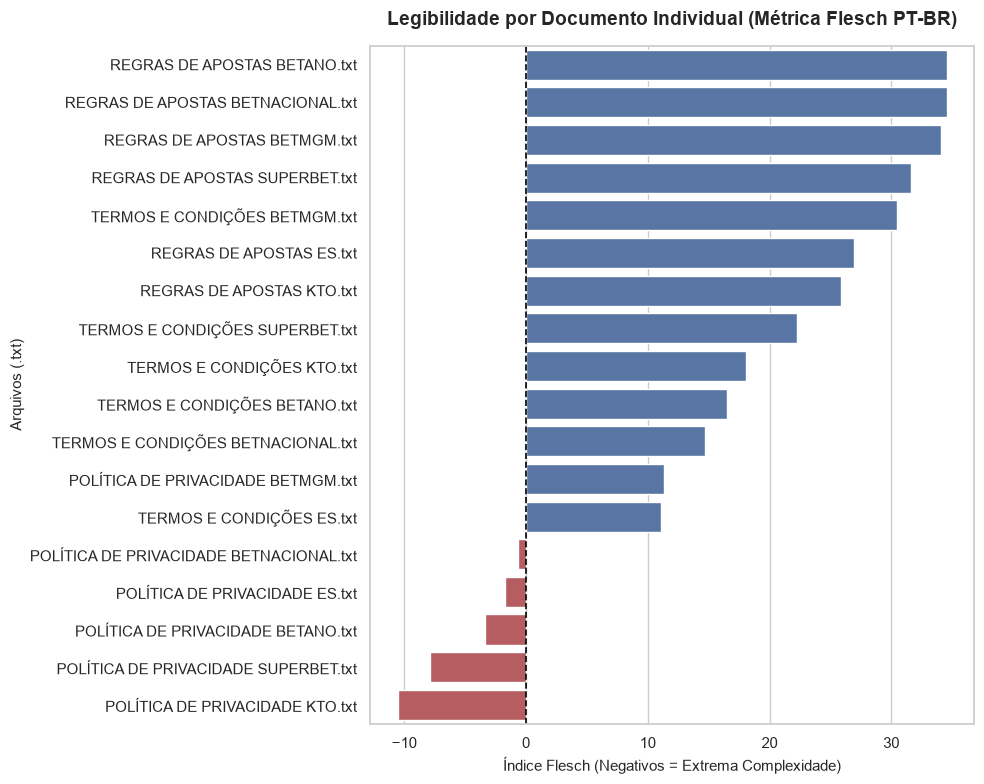

In [34]:
# Exibição de gráfico para visualização das pontuações resultantes da execução anterior
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos dados: Extrai apenas o nome curto do arquivo para não poluir o eixo Y
df_conteudo['nome_arquivo_curto'] = df_conteudo['caminho_arquivo'].apply(os.path.basename)

# Ordena o DataFrame do texto mais fácil para o mais difícil
df_plot = df_conteudo.sort_values(by='indice_flesch', ascending=False)

# Configura a janela do gráfico
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# ----------------------------------------------------------------------
# GRÁFICO: Barras Horizontais Divergentes (Comparação Individual)
# ----------------------------------------------------------------------
# Cria uma paleta de cores condicional baseada no dataframe já ordenado:
# Azul para legível (pontuação >=0) e Vermelho para complexo (pontuação <0)
cores = ['#4c72b0' if x >= 0 else '#c44e52' for x in df_plot['indice_flesch']]

# Plota o gráfico de barras
sns.barplot(
    x='indice_flesch', 
    y='nome_arquivo_curto', 
    data=df_plot,
    palette=cores,
    hue='nome_arquivo_curto',
    legend=False
)

# Linha de corte no Marco Zero para enfatizar os textos negativos/técnicos
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)

# Configuração de títulos e rótulos
plt.title('Legibilidade por Documento Individual (Métrica Flesch PT-BR)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Índice Flesch (Negativos = Extrema Complexidade)', fontsize=11)
plt.ylabel('Arquivos (.txt)', fontsize=11)

# ----------------------------------------------------------------------
# Ajustes Finais de Exibição
# ----------------------------------------------------------------------
plt.tight_layout() #Ajuste de margens das figuras
plt.show() #Limpa a memória

In [21]:
#Pré-processamento dos textos

import nltk
import re
from nltk.corpus import stopwords

# Baixando as stopwords em português
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

def preprocessar_texto(texto):
    if not isinstance(texto, str):  
        return ""

    # 1. Converter para minúsculo
    texto = texto.lower()

    # 2. Remover links e caracteres especiais/pontuação (mantendo apenas letras)
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    texto = re.sub(r'[^a-záàâãéèêíïóôõöúç\s]', '', texto)

    # 3. Tokenização e remoção de stopwords
    palavras = texto.split()
    palavras_limpas = [w for w in palavras if w not in stop_words and len(w) > 2]

    return " ".join(palavras_limpas)

# Criando a nova coluna para mostrar o texto resultante após os passos de pré processamento aplicados
print("Iniciando o pré-processamento...")
df_conteudo['texto_processado'] = df_conteudo['conteúdo do texto'].apply(preprocessar_texto)

# Exibindo resultado
print("Pré-processamento concluído!")
display(df_conteudo[['caminho_arquivo', 'conteúdo do texto', 'texto_processado']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Iniciando o pré-processamento...
Pré-processamento concluído!


,caminho_arquivo,conteúdo do texto,texto_processado
0,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Aviso de Privacidade\n1. Escopo | 2. Tipos e ...,aviso privacidade escopo tipos uso informações...
1,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Regras de Apostas\n1. Regras Gerais de Aposta...,regras apostas regras gerais apostas regras di...
2,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,﻿Termos e Condições\nÚltima atualização: 22/04...,termos condições última atualização nota impor...
3,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,1. Introdução\nA presente Política de Privacid...,introdução presente política privacidade escla...
4,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,Regras gerais\n\n\nAs regras gerais de liquida...,regras gerais regras gerais liquidação estabel...


In [ ]:
# Análise da frequencia individual das palavras individuais

from collections import Counter

#Função para contar as palavras de um único texto e retornar as 10 mais comuns.
def obter_top_palavras(texto, top_n=10):
    if not isinstance(texto, str) or not texto.strip():
        return {}
    
    palavras = texto.split()
    contagem = Counter(palavras)
    
    # Retorna um dicionário com a estrutura {palavra: frequencia}
    return dict(contagem.most_common(top_n))

# Aplicar a função linha por linha para analisar cada texto individualmente
df_conteudo['frequencia_individual'] = df_conteudo['texto_processado'].apply(lambda x: obter_top_palavras(x, top_n=10))

# Exibir o resultado em formato tabular para fácil leitura
print("Análise de frequência individual concluída!")

#display(df_conteudo[['caminho_arquivo', 'texto_processado', 'frequencia_individual']].head())
display(df_conteudo[['caminho_arquivo', 'texto_processado', 'frequencia_individual']].head())

Análise de frequência individual concluída!


,caminho_arquivo,texto_processado,frequencia_individual
0,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,aviso privacidade escopo tipos uso informações...,"{'dados': 138, 'informações': 74, 'pessoais': ..."
1,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,regras apostas regras gerais apostas regras di...,"{'apostas': 935, 'pontos': 471, 'jogador': 456..."
2,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,termos condições última atualização nota impor...,"{'betano': 276, 'apostas': 183, 'conta': 171, ..."
3,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,introdução presente política privacidade escla...,"{'dados': 51, 'pessoais': 17, 'proteção': 16, ..."
4,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,regras gerais regras gerais liquidação estabel...,"{'partida': 350, 'preveja': 322, 'apostas': 25..."


In [54]:
# Gráfico para exibição visual da análise da frequência individual das palavras por arquivo

import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Criar uma pasta para salvar os gráficos isolados
pasta_graficos = 'Graficos_FreqInd_Separados'
os.makedirs(pasta_graficos, exist_ok=True)

# Limite de textos a serem processados
df_alvo = df_conteudo.iloc[:18] 

print(f"Gerando gráficos individuais para {len(df_alvo)} textos...\n")

# Iterar sobre cada linha do DataFrame
# Para cada plataforma serão gerados os gráficos na ordem: 1- Política; 2- Regras; 3- Termos
for index, linha in df_alvo.iterrows():
    dados_frequencia = linha['frequencia_individual']
    caminho_arquivo = linha['caminho_arquivo']
    nome_base = os.path.basename(caminho_arquivo)
    nome_sem_extensao = os.path.splitext(nome_base)[0]
    
    # Verifica se o documento tem dados suficientes
    if not dados_frequencia:
        print(f"Pulo: Sem palavras processadas para {nome_base}")
        continue
        
    try:
        # Estruturar dados do gráfico
        df_grafico = pd.DataFrame(list(dados_frequencia.items()), columns=['Palavra', 'Frequência'])
        df_grafico = df_grafico.sort_values(by='Frequência', ascending=False)
        
        # Criar uma imagem para este gráfico específico
        plt.figure(figsize=(10, 6))
        
        # Plotar o gráfico no Seaborn
        sns.barplot(
            x='Frequência', 
            y='Palavra', 
            data=df_grafico, 
            palette='Blues_r', 
            hue='Palavra', 
            legend=False
        )
        
        # Configurar títulos e outros parâmetros da imagem individual
        plt.title(f"Palavras mais Frequentes\n{nome_sem_extensao}", fontsize=14, weight='normal', pad=15)
        plt.xlabel("Quantidade de Ocorrências (Frequência Absoluta)", fontsize=11)
        plt.ylabel("Palavras", fontsize=11) 
        plt.tight_layout()  # Ajuste de margens das figuras
        
        # Salvar a imagem na pasta criada
        caminho_salvamento = os.path.join(pasta_graficos, f"{nome_sem_extensao}.png")
        plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
        
        #plt.show()   # Exibe o gráfico
        plt.close()  # Fecha o gráfico atual para liberar a memória

        print(f"Sucesso: Salva em '{caminho_salvamento}'")  
        
    except Exception as e:
        print(f"Erro ao gerar gráfico para {nome_base}: {e}")

print(f"\nProcesso concluído! Gráficos individuais gerados (e salvos na pasta '{pasta_graficos}')")

Gerando gráficos individuais para 18 textos...

Sucesso: Salva em 'Graficos_FreqInd_Separados\POLÍTICA DE PRIVACIDADE BETANO.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\REGRAS DE APOSTAS BETANO.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\TERMOS E CONDIÇÕES BETANO.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\POLÍTICA DE PRIVACIDADE ES.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\REGRAS DE APOSTAS ES.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\TERMOS E CONDIÇÕES ES.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\POLÍTICA DE PRIVACIDADE SUPERBET.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\REGRAS DE APOSTAS SUPERBET.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\TERMOS E CONDIÇÕES SUPERBET.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\POLÍTICA DE PRIVACIDADE BETMGM.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\REGRAS DE APOSTAS BETMGM.png'
Sucesso: Salva em 'Graficos_FreqInd_Separados\TERMOS E CONDIÇÕES BETMGM.png'
Sucesso: Salva em 

In [35]:
# Análise dos trigramas por arquivo

from collections import Counter
import pandas as pd
from nltk.util import ngrams

#Função para extrair os 10 trigramas mais comuns de cada texto analisado.
def obter_top_trigramas(texto, top_n=10):
    
    if not isinstance(texto, str) or not texto.strip():
        return {}
    
    palavras = texto.split()
    
    # Gerar os trigramas 
    lista_trigramas = list(ngrams(palavras, 3))
    
    # Se o texto for muito curto e tiver menos de 3 palavras, retorna vazio
    if not lista_trigramas:
        return {}
    
    # Unir as tuplas com espaços para que fiquem legíveis (ex: "palavra1 palavra2 palavra3")
    trigramas_formatados = [" ".join(trigrama) for trigrama in lista_trigramas]
    
    # Contar a frequência
    contagem = Counter(trigramas_formatados)
    
    return dict(contagem.most_common(top_n))

# Aplicar a função linha por linha no DataFrame
df_conteudo['trigramas_individuais'] = df_conteudo['texto_processado'].apply(lambda x: obter_top_trigramas(x, top_n=10))

# Exibir o resultado
print("Análise de Trigramas por texto concluída!")
display(df_conteudo[['caminho_arquivo', 'texto_processado', 'trigramas_individuais']].head())

Análise de Trigramas por texto concluída!


,caminho_arquivo,texto_processado,trigramas_individuais
0,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,aviso privacidade escopo tipos uso informações...,"{'dados identificação pessoal': 12, 'previdênc..."
1,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,regras apostas regras gerais apostas regras di...,"{'todas apostas anuladas': 55, 'lugar pontos l..."
2,Documentos_Bets_Extraidos\Dataset Bets\1.BETAN...,termos condições última atualização nota impor...,"{'betano reserva direito': 13, 'todos demais m..."
3,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,introdução presente política privacidade escla...,"{'esportes gaming brasil': 6, 'lei geral prote..."
4,Documentos_Bets_Extraidos\Dataset Bets\2.ESPOR...,regras gerais regras gerais liquidação estabel...,"{'todas apostas nesta': 66, 'apostas nesta sel..."


In [ ]:
#Geração de gráfico para visualização

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Criar uma pasta para salvar os gráficos isolados
pasta_graficos_trig = 'Graficos_Trigramas_Separados'
os.makedirs(pasta_graficos, exist_ok=True)

#Limite de textos a serem processados
df_alvo = df_conteudo.iloc[:18]

print(f"Gerando gráficos individuais para {len(df_conteudo)} textos...\n")

# Iterar sobre cada linha do DataFrame
for index, linha in df_conteudo.iterrows():
    dados_trigramas = linha['trigramas_individuais']
    caminho_arquivo = linha['caminho_arquivo']
    nome_base = os.path.basename(caminho_arquivo)
    nome_sem_extensao = os.path.splitext(nome_base)[0]
    
    # Verifica se o documento tem trigramas suficientes
    if not dados_trigramas:
        print(f"Pulo: Sem trigramas para {nome_base}")
        continue
        
    try:
        # Estruturar dados do gráfico
        df_grafico = pd.DataFrame(list(dados_trigramas.items()), columns=['Trigrama', 'Frequência'])
        df_grafico = df_grafico.sort_values(by='Frequência', ascending=False)
        
        # Criar uma imagem para este gráfico específico
        plt.figure(figsize=(10, 6))
        
        # Plotar o gráfico no Seaborn
        sns.barplot(
            x='Frequência', 
            y='Trigrama', 
            data=df_grafico, 
            palette='Purples_r', 
            hue='Trigrama',
            legend=False
        )
        
        # Configurar títulos e outros parâmtros da imagem individual
        plt.title(f"Trigramas mais Frequentes\n{nome_sem_extensao}", fontsize=14, weight='normal', pad=15)
        plt.xlabel("Ocorrências (Frequência Absoluta)", fontsize=11)
        plt.ylabel("Trigramas", fontsize=11)
        plt.tight_layout() #Ajuste de margens das figuras


        # Salvar a imagem na pasta criada
        caminho_salvamento = os.path.join(pasta_graficos_trig, f"{nome_sem_extensao}.png")
        plt.savefig(caminho_salvamento, dpi=150, bbox_inches='tight')


        #plt.show() #Exibe o gráfico
        plt.close() #Fechar a figura atual para liberar a memória antes de gerar o próximo gráfico

        print(f"Sucesso: Salva em '{caminho_salvamento}'")   
        
    except Exception as e:
         print(f"Erro ao gerar gráfico para {nome_base}: {e}")

print(f"\nProcesso concluído! Gráficos individuais gerados (e salvos na pasta '{pasta_graficos_trig}')")

Gerando gráficos individuais para 18 textos...

Sucesso: Salva em 'Graficos_Trigramas_Separados\POLÍTICA DE PRIVACIDADE BETANO.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\REGRAS DE APOSTAS BETANO.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\TERMOS E CONDIÇÕES BETANO.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\POLÍTICA DE PRIVACIDADE ES.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\REGRAS DE APOSTAS ES.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\TERMOS E CONDIÇÕES ES.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\POLÍTICA DE PRIVACIDADE SUPERBET.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\REGRAS DE APOSTAS SUPERBET.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\TERMOS E CONDIÇÕES SUPERBET.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\POLÍTICA DE PRIVACIDADE BETMGM.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\REGRAS DE APOSTAS BETMGM.png'
Sucesso: Salva em 'Graficos_Trigramas_Separados\TERMOS E CONDIÇÕES BETMGM

In [ ]:
#Gerar Núvem de Palavras para cada arquivo

import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Criar uma pasta para salvar as nuvens de palavras (se ela não existir)

pasta_saida = 'Nuvens_de_Palavras_Por_Texto'

os.makedirs(pasta_saida, exist_ok=True)

# Configurar a lista de Stopwords em Português

lista_stopwords = set(STOPWORDS)

stopwords_pt = [

    "de", "a", "o", "que", "e", "do", "da", "em", "um", "para", "é", "with", "com", "não",
    "uma", "os", "as", "no", "na", "nos", "nas", "por", "mais", "ao", "aos", "como",
    "dos", "das", "se", "sua", "seu", "seus", "suas", "ou", "ser", "quando", "muito",
    "há", "está", "estão", "pelo", "pela", "pelos", "pelas", "são", "foi"

]

lista_stopwords.update(stopwords_pt)

print("Iniciando a geração das nuvens de palavras individuais...")

# Iterar por cada linha do DataFrame

for index, linha in df_conteudo.iterrows():
    texto_doc = str(linha['conteúdo do texto']).strip()
    caminho_original = linha['caminho_arquivo']

    # Ignora documentos que estejam vazios
    if not texto_doc:
        continue

    # Extrai o nome limpo do arquivo e remove a extensão .txt
    nome_base = os.path.basename(caminho_original)
    nome_sem_extensao = os.path.splitext(nome_base)[0]
    try:
        # Gerar a nuvem de palavras para o texto atual
        nuvem_individual = WordCloud(

            width=800,
            height=500,
            background_color='white',
            stopwords=lista_stopwords,
            max_words=50,                
            colormap='viridis',
            min_font_size=10

        ).generate(texto_doc)

        # Criar e configurar o gráfico
        plt.figure(figsize=(10, 6))
        plt.imshow(nuvem_individual, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Nuvem de Palavras: {nome_base}', fontsize=14, weight='bold', pad=15)
    
        # Salvar a imagem na pasta criada
        caminho_salvamento = os.path.join(pasta_saida, f'nuvem_{nome_sem_extensao}.png')
        plt.savefig(caminho_salvamento, dpi=150, bbox_inches='tight')

        plt.close()  # Fecha o gráfico atual para liberar a memória do computador   

        print(f"Sucesso: Salva em '{caminho_salvamento}'")       

    except Exception as e:

        print(f"Erro ao gerar nuvem para {nome_base}: {e}")

print(f"\nProcesso concluído! Todas as nuvens foram salvas na pasta: '{pasta_saida}'") 

Iniciando a geração das nuvens de palavras individuais...
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_POLÍTICA DE PRIVACIDADE BETANO.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_REGRAS DE APOSTAS BETANO.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_TERMOS E CONDIÇÕES BETANO.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_POLÍTICA DE PRIVACIDADE ES.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_REGRAS DE APOSTAS ES.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_TERMOS E CONDIÇÕES ES.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_POLÍTICA DE PRIVACIDADE SUPERBET.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_REGRAS DE APOSTAS SUPERBET.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_TERMOS E CONDIÇÕES SUPERBET.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_POLÍTICA DE PRIVACIDADE BETMGM.png'
Sucesso: Salva em 'Nuvens_de_Palavras_Por_Texto\nuvem_REGRAS DE APOSTAS BETMGM.pn